In [1]:
'''
БЛОК 1. ИМПОРТЫ, НАСТРОЙКА ЭКСПЕРИМЕНТА И ПРОВЕРКА ФАЙЛОВ ДАТАСЕТА (ЛР №4)

Что делает этот блок:
1) Подключает все нужные библиотеки для работы с текстами, трансформерами, метриками и графиками.
2) Фиксирует случайность (seed), чтобы результаты можно было повторить.
3) Выбирает устройство вычислений (GPU или CPU).
4) Задает пути к train/validation/test файлам TweetEval (sentiment).
5) Делает базовую проверку: существуют ли файлы и какие у нас ключевые гиперпараметры.

Почему это важно:
- Без единой конфигурации и seed результаты от запуска к запуску могут отличаться.
- Если сразу не проверить пути, можно потерять время на ошибки позже.
- Этот блок — фундамент всего ноутбука: после него у нас есть единая «точка правды» для всех следующих шагов.

Замечание:
- Мы НЕ обучаем модель в этом блоке, только подготавливаем среду.
- На следующем блоке уже загрузим CSV и сделаем EDA (анализ данных).
'''

import os  # Работа с путями и переменными окружения.
import random  # Генератор случайных чисел из стандартной библиотеки Python.
from pathlib import Path  # Удобный объектный интерфейс для путей к файлам и папкам.

import numpy as np  # Численные операции и массивы.
import pandas as pd  # Табличные данные (CSV, DataFrame).
import matplotlib.pyplot as plt  # Базовые графики.
import seaborn as sns  # Красивые статистические графики.

import torch  # PyTorch: тензоры, модели, обучение.
import torch.nn as nn  # Нейросетевые слои.
from torch.utils.data import Dataset, DataLoader  # Классы для датасета и батчевой загрузки.

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix  # Метрики классификации.

from transformers import AutoTokenizer, AutoModelForSequenceClassification  # Токенизатор и предобученные модели HuggingFace.

SEED = 42  # Фиксированное значение случайности для воспроизводимости.
random.seed(SEED)  # Фиксируем случайность в random.
np.random.seed(SEED)  # Фиксируем случайность в NumPy.
torch.manual_seed(SEED)  # Фиксируем случайность в PyTorch на CPU.
torch.cuda.manual_seed_all(SEED)  # Фиксируем случайность на всех CUDA-устройствах (если есть GPU).

torch.backends.cudnn.deterministic = True  # Включаем более детерминированный режим cuDNN.
torch.backends.cudnn.benchmark = False  # Отключаем авто-подбор алгоритмов ради повторяемости.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Выбираем GPU, если доступен, иначе CPU.
print(f"Устройство: {device}")  # Показываем, где будут выполняться вычисления.

BASE_DIR = Path(r"d:\6_семестр\Машинное обучение и большие данные\лаб2")  # Корневая папка текущей лабораторной.
TRAIN_PATH = BASE_DIR / "sentiment_train.csv"  # Путь к обучающей выборке.
VAL_PATH = BASE_DIR / "sentiment_validation.csv"  # Путь к валидационной выборке.
TEST_PATH = BASE_DIR / "sentiment_test.csv"  # Путь к тестовой выборке.

assert TRAIN_PATH.exists(), f"Файл не найден: {TRAIN_PATH}"  # Проверяем наличие train-файла.
assert VAL_PATH.exists(), f"Файл не найден: {VAL_PATH}"  # Проверяем наличие validation-файла.
assert TEST_PATH.exists(), f"Файл не найден: {TEST_PATH}"  # Проверяем наличие test-файла.

MAX_LEN = 128  # Максимальная длина последовательности токенов после токенизации.
BATCH_SIZE = 32  # Размер батча (если не влезает в GPU-память, уменьшить до 16 или 8).
NUM_CLASSES = 3  # Число классов для sentiment (label: 0, 1, 2).

LR_CUSTOM = 1e-3  # Learning rate для собственной модели (обычно можно чуть выше).
LR_BERT = 2e-5  # Learning rate для fine-tuning DistilBERT (обычно меньше, чем у модели с нуля).
EPOCHS_CUSTOM = 2  # Максимум эпох для своей модели (early stopping остановит раньше при необходимости).
EPOCHS_BERT = 4  # Максимум эпох для DistilBERT fine-tuning.
PATIENCE = 3  # Терпение early stopping: сколько эпох без улучшения ждать.

MODEL_NAME = "distilbert-base-uncased"  # Базовая предобученная модель DistilBERT для англоязычных твитов.
SAVE_DIR = BASE_DIR / "lab4_checkpoints"  # Папка для сохранения лучших весов моделей.
SAVE_DIR.mkdir(parents=True, exist_ok=True)  # Создаем папку, если ее еще нет.

CONFIG = {  # Собираем ключевые настройки в единый словарь для удобства логирования.
    "SEED": SEED,  # Seed для воспроизводимости.
    "MAX_LEN": MAX_LEN,  # Максимальная длина токенов.
    "BATCH_SIZE": BATCH_SIZE,  # Размер батча.
    "NUM_CLASSES": NUM_CLASSES,  # Число классов.
    "LR_CUSTOM": LR_CUSTOM,  # Скорость обучения своей модели.
    "LR_BERT": LR_BERT,  # Скорость обучения DistilBERT.
    "EPOCHS_CUSTOM": EPOCHS_CUSTOM,  # Макс. эпох своей модели.
    "EPOCHS_BERT": EPOCHS_BERT,  # Макс. эпох DistilBERT.
    "PATIENCE": PATIENCE,  # Параметр early stopping.
    "MODEL_NAME": MODEL_NAME,  # Имя предобученной модели.
    "TRAIN_PATH": str(TRAIN_PATH),  # Строковый путь train-файла.
    "VAL_PATH": str(VAL_PATH),  # Строковый путь validation-файла.
    "TEST_PATH": str(TEST_PATH),  # Строковый путь test-файла.
    "SAVE_DIR": str(SAVE_DIR),  # Строковый путь к папке чекпоинтов.
}  # Завершаем словарь конфигурации.

print("Конфигурация эксперимента:")  # Заголовок для читаемого вывода параметров.
for k, v in CONFIG.items():  # Идем по всем парам ключ-значение из конфигурации.
    print(f"{k}: {v}")  # Печатаем каждую настройку в формате "ключ: значение".

Устройство: cpu
Конфигурация эксперимента:
SEED: 42
MAX_LEN: 128
BATCH_SIZE: 32
NUM_CLASSES: 3
LR_CUSTOM: 0.001
LR_BERT: 2e-05
EPOCHS_CUSTOM: 2
EPOCHS_BERT: 4
PATIENCE: 3
MODEL_NAME: distilbert-base-uncased
TRAIN_PATH: d:\6_семестр\Машинное обучение и большие данные\лаб2\sentiment_train.csv
VAL_PATH: d:\6_семестр\Машинное обучение и большие данные\лаб2\sentiment_validation.csv
TEST_PATH: d:\6_семестр\Машинное обучение и большие данные\лаб2\sentiment_test.csv
SAVE_DIR: d:\6_семестр\Машинное обучение и большие данные\лаб2\lab4_checkpoints


Размеры выборок:
train: (45615, 2)
val:   (2000, 2)
test:  (12284, 2)

Типы колонок train:
text       str
label    int64
dtype: object

[train] missing={'text': 0, 'label': 0}, duplicate_rows=26, duplicate_text=29

[val] missing={'text': 0, 'label': 0}, duplicate_rows=0, duplicate_text=0

[test] missing={'text': 0, 'label': 0}, duplicate_rows=0, duplicate_text=0

Распределение классов [train]:
       count  ratio_%
label                
0       7093    15.55
1      20673    45.32
2      17849    39.13

Распределение классов [val]:
       count  ratio_%
label                
0        312    15.60
1        869    43.45
2        819    40.95

Распределение классов [test]:
       count  ratio_%
label                
0       3972    32.33
1       5937    48.33
2       2375    19.33

Статистика длин [train]: {'n': 45615, 'char_mean': np.float64(106.93), 'char_median': 113, 'char_p95': 141, 'word_mean': np.float64(19.24), 'word_median': 20, 'word_p95': 27}

Статистика длин [val]: {'n': 2000, 

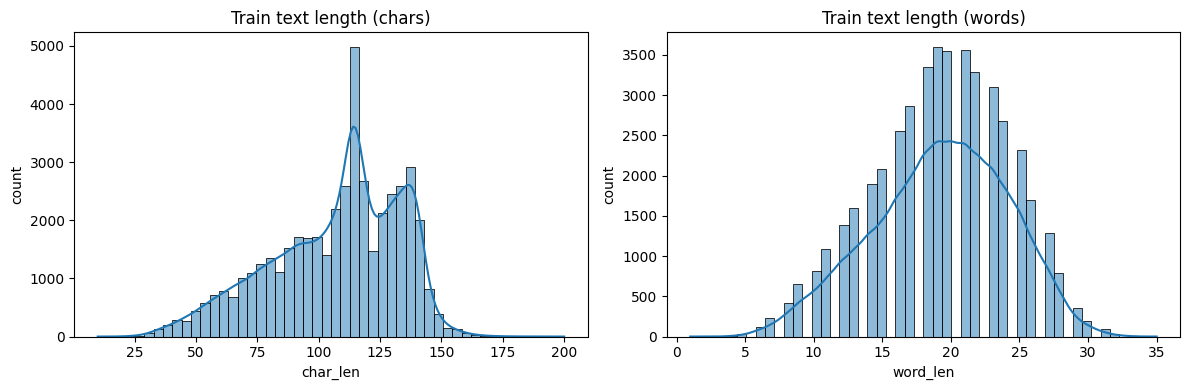

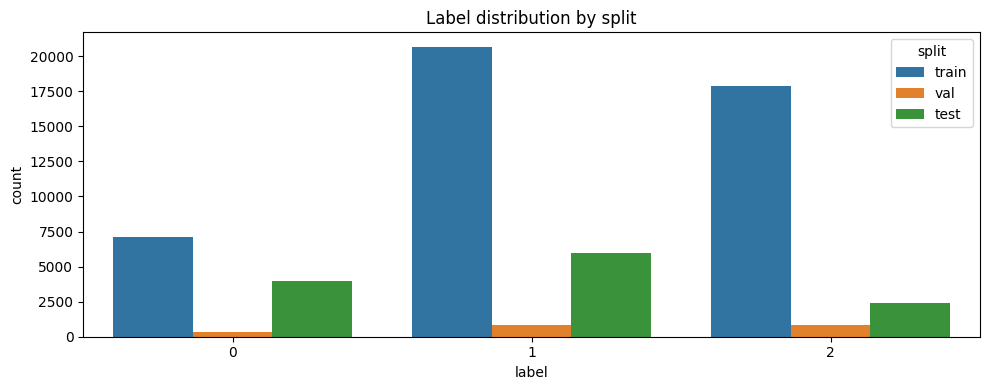


Примеры текстов из train:


,text,label
0,"""QT @user In the original draft of the 7th boo...",2
1,"""Ben Smith / Smith (concussion) remains out of...",1
2,Sorry bout the stream last night I crashed out...,1
3,Chase Headley's RBI double in the 8th inning o...,1
4,@user Alciato: Bee will invest 150 million in ...,2


In [2]:
'''
БЛОК 2. ЗАГРУЗКА CSV, ПЕРВИЧНЫЙ EDA И БАЗОВАЯ ДИАГНОСТИКА ДАТАСЕТА (TweetEval Sentiment)

Что делает этот блок:
1) Загружает train/validation/test из CSV в DataFrame.
2) Проверяет структуру данных: размеры, названия колонок, типы, пропуски.
3) Проверяет дубликаты (полные строки и дубликаты только по тексту).
4) Считает распределение классов по выборкам и показывает его в числах и процентах.
5) Анализирует длины текстов (в символах и словах), строит гистограммы.
6) Формирует компактную сводную таблицу, которую удобно вставлять в отчёт.

Почему это важно:
- Мы заранее видим возможные проблемы (дисбаланс, шум, дубликаты).
- Это помогает правильно интерпретировать метрики позже (особенно macro-F1).
- На основе длины текстов мы обосновываем выбор MAX_LEN для токенизации.

Итог блока:
- train_df, val_df, test_df готовы к дальнейшей предобработке.
- Получены числовые и графические факты о данных для раздела отчёта «Описание датасета».
'''

train_df = pd.read_csv(TRAIN_PATH)  # Загружаем обучающую выборку из CSV в DataFrame.
val_df = pd.read_csv(VAL_PATH)  # Загружаем валидационную выборку из CSV в DataFrame.
test_df = pd.read_csv(TEST_PATH)  # Загружаем тестовую выборку из CSV в DataFrame.

print("Размеры выборок:")  # Печатаем заголовок для читаемого вывода.
print(f"train: {train_df.shape}")  # Выводим размер train (строки, колонки).
print(f"val:   {val_df.shape}")  # Выводим размер validation (строки, колонки).
print(f"test:  {test_df.shape}")  # Выводим размер test (строки, колонки).

required_cols = {"text", "label"}  # Задаем обязательные колонки по условию задачи классификации.
assert required_cols.issubset(train_df.columns), "В train нет колонок text/label"  # Проверяем, что train содержит нужные колонки.
assert required_cols.issubset(val_df.columns), "В val нет колонок text/label"  # Проверяем, что validation содержит нужные колонки.
assert required_cols.issubset(test_df.columns), "В test нет колонок text/label"  # Проверяем, что test содержит нужные колонки.

print("\nТипы колонок train:")  # Заголовок перед выводом типов колонок.
print(train_df.dtypes)  # Печатаем типы колонок в train для контроля корректного чтения CSV.

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:  # Последовательно обрабатываем все три выборки.
    missing = df[["text", "label"]].isna().sum().to_dict()  # Считаем количество пропусков по ключевым колонкам.
    dup_rows = int(df.duplicated().sum())  # Считаем число полных дубликатов строк.
    dup_text = int(df.duplicated(subset=["text"]).sum())  # Считаем дубликаты только по тексту.
    print(f"\n[{name}] missing={missing}, duplicate_rows={dup_rows}, duplicate_text={dup_text}")  # Печатаем итоги диагностики качества данных.

label_tables = {}  # Создаем словарь для хранения таблиц распределения классов по выборкам.
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:  # Идем по каждой выборке для подсчета классов.
    counts = df["label"].value_counts(dropna=False).sort_index()  # Считаем количество объектов каждого класса label.
    ratios = (counts / len(df) * 100).round(2)  # Переводим абсолютные количества в проценты.
    label_tables[name] = pd.DataFrame({"count": counts, "ratio_%": ratios})  # Сохраняем таблицу count+ratio для текущей выборки.
    print(f"\nРаспределение классов [{name}]:")  # Заголовок распределения классов для конкретной выборки.
    print(label_tables[name])  # Печатаем таблицу распределения классов.

for df in [train_df, val_df, test_df]:  # Применяем одинаковую базовую текстовую нормализацию ко всем выборкам.
    df["text"] = df["text"].astype(str).str.strip()  # Приводим text к строкам и убираем пробелы по краям.
    df["char_len"] = df["text"].str.len()  # Добавляем длину текста в символах.
    df["word_len"] = df["text"].str.split().str.len()  # Добавляем длину текста в словах (по пробелам).

def describe_lengths(df, name):  # Определяем функцию компактной статистики длин текстов для одной выборки.
    stats = {  # Формируем словарь ключевых статистик для отчёта.
        "n": len(df),  # Число примеров в выборке.
        "char_mean": round(df["char_len"].mean(), 2),  # Средняя длина текста в символах.
        "char_median": int(df["char_len"].median()),  # Медианная длина в символах.
        "char_p95": int(df["char_len"].quantile(0.95)),  # 95-й перцентиль длины в символах.
        "word_mean": round(df["word_len"].mean(), 2),  # Средняя длина текста в словах.
        "word_median": int(df["word_len"].median()),  # Медианная длина в словах.
        "word_p95": int(df["word_len"].quantile(0.95)),  # 95-й перцентиль длины в словах.
    }  # Закрываем словарь статистик.
    print(f"\nСтатистика длин [{name}]: {stats}")  # Печатаем статистику длин для текущей выборки.
    return stats  # Возвращаем словарь, чтобы потом собрать общую таблицу.

len_stats_train = describe_lengths(train_df, "train")  # Считаем и печатаем статистику длин train.
len_stats_val = describe_lengths(val_df, "val")  # Считаем и печатаем статистику длин validation.
len_stats_test = describe_lengths(test_df, "test")  # Считаем и печатаем статистику длин test.

summary_df = pd.DataFrame([  # Создаем итоговую сводную таблицу по размерам и длинам всех выборок.
    {"split": "train", **len_stats_train},  # Добавляем строку train.
    {"split": "val", **len_stats_val},  # Добавляем строку validation.
    {"split": "test", **len_stats_test},  # Добавляем строку test.
])  # Закрываем создание DataFrame.
print("\nИтоговая сводка по выборкам:")  # Заголовок перед итоговой таблицей.
print(summary_df)  # Печатаем итоговую таблицу для отчёта.

plt.figure(figsize=(12, 4))  # Создаем область рисунка для двух графиков длины текста.
plt.subplot(1, 2, 1)  # Выбираем левый подграфик (длина в символах).
sns.histplot(train_df["char_len"], bins=50, kde=True)  # Строим гистограмму длины train-текстов в символах.
plt.title("Train text length (chars)")  # Заголовок графика по символам.
plt.xlabel("char_len")  # Подпись оси X (длина в символах).
plt.ylabel("count")  # Подпись оси Y (количество примеров).

plt.subplot(1, 2, 2)  # Выбираем правый подграфик (длина в словах).
sns.histplot(train_df["word_len"], bins=50, kde=True)  # Строим гистограмму длины train-текстов в словах.
plt.title("Train text length (words)")  # Заголовок графика по словам.
plt.xlabel("word_len")  # Подпись оси X (длина в словах).
plt.ylabel("count")  # Подпись оси Y (количество примеров).
plt.tight_layout()  # Автоматически подгоняем отступы, чтобы подписи не налезали.
plt.show()  # Показываем графики.

plt.figure(figsize=(10, 4))  # Создаем отдельный график для сравнения распределения классов между split.
label_compare = pd.concat([  # Собираем длинную таблицу для удобного barplot.
    train_df.assign(split="train"),  # Добавляем train с меткой split.
    val_df.assign(split="val"),  # Добавляем validation с меткой split.
    test_df.assign(split="test"),  # Добавляем test с меткой split.
], ignore_index=True)  # Склеиваем в один DataFrame и пересобираем индекс.
sns.countplot(data=label_compare, x="label", hue="split")  # Рисуем столбчатую диаграмму классов по каждому split.
plt.title("Label distribution by split")  # Заголовок графика распределения классов.
plt.xlabel("label")  # Подпись оси X (класс).
plt.ylabel("count")  # Подпись оси Y (количество объектов).
plt.tight_layout()  # Корректируем расположение элементов графика.
plt.show()  # Показываем график распределения классов.

print("\nПримеры текстов из train:")  # Заголовок перед примерами реальных текстов.
display(train_df[["text", "label"]].head(5))  # Показываем первые 5 примеров, чтобы визуально проверить данные.

In [3]:
'''
БЛОК 3A. ПОДГОТОВКА ДАННЫХ ДЛЯ СОБСТВЕННОГО ENCODER-ONLY TRANSFORMER
(ТОКЕНИЗАЦИЯ, СЛОВАРЬ, PADDING, MASK, DATASET, DATALOADER)

Что делает этот блок:
1) Готовит тексты для собственной модели (не для BERT).
2) Строит словарь только по train (чтобы не было утечки информации из val/test).
3) Преобразует тексты в последовательности индексов токенов.
4) Выполняет обрезку/дополнение до MAX_LEN.
5) Создает attention_mask (1 для реального токена, 0 для PAD).
6) Формирует PyTorch Dataset и DataLoader для train/val/test.

Почему это важно:
- Собственный трансформер не умеет принимать строки, ему нужны числа.
- Разные длины текстов нужно привести к одной длине, чтобы обучать батчами.
- attention_mask нужен, чтобы модель не «училась» на искусственных PAD-токенах.

Ключевые решения:
- Используем простую word-level токенизацию через regex.
- Спецтокены:
    [PAD] -> 0  (для добивки коротких последовательностей)
    [UNK] -> 1  (для слов, которых нет в словаре train)
- MAX_VOCAB_SIZE ограничивает словарь, чтобы память не росла бесконтрольно.
'''

import re  # Импортируем модуль регулярных выражений для простой токенизации текста.
from collections import Counter  # Импортируем Counter для подсчета частот слов в train.

MAX_VOCAB_SIZE = 30000  # Ограничиваем максимальный размер словаря для собственной модели.
PAD_TOKEN = "[PAD]"  # Специальный токен для padding коротких последовательностей.
UNK_TOKEN = "[UNK]"  # Специальный токен для неизвестных слов вне словаря train.
PAD_ID = 0  # Индекс PAD-токена в словаре (всегда 0 для удобства маскирования).
UNK_ID = 1  # Индекс UNK-токена в словаре (всегда 1).

def simple_tokenize(text):  # Объявляем функцию простой токенизации строки в список токенов.
    text = str(text).lower().strip()  # Приводим текст к нижнему регистру и убираем пробелы по краям.
    tokens = re.findall(r"[a-z0-9']+|[^\w\s]", text)  # Выделяем слова/числа и отдельно знаки пунктуации.
    return tokens  # Возвращаем список токенов.

train_tokens_list = train_df["text"].apply(simple_tokenize).tolist()  # Токенизируем все train-тексты для построения словаря.
val_tokens_list = val_df["text"].apply(simple_tokenize).tolist()  # Токенизируем все val-тексты.
test_tokens_list = test_df["text"].apply(simple_tokenize).tolist()  # Токенизируем все test-тексты.

token_counter = Counter()  # Создаем счетчик частот токенов.
for toks in train_tokens_list:  # Проходим по всем token-спискам из train.
    token_counter.update(toks)  # Добавляем частоты токенов текущего текста в общий счетчик.

most_common_tokens = token_counter.most_common(MAX_VOCAB_SIZE - 2)  # Берем самые частые токены с учетом мест под PAD и UNK.
itos = [PAD_TOKEN, UNK_TOKEN] + [tok for tok, _ in most_common_tokens]  # Формируем список "index-to-string": сначала спецтокены, потом обычные.
stoi = {tok: idx for idx, tok in enumerate(itos)}  # Формируем словарь "string-to-index" для быстрого перевода токенов в числа.

vocab_size = len(itos)  # Итоговый размер словаря после ограничения.
print(f"Размер словаря (с учетом PAD/UNK): {vocab_size}")  # Печатаем размер словаря для контроля.
print("Первые 20 токенов словаря:", itos[:20])  # Печатаем начало словаря для визуальной проверки.

def encode_tokens(tokens, stoi_map):  # Объявляем функцию перевода списка токенов в список индексов.
    return [stoi_map.get(tok, UNK_ID) for tok in tokens]  # Для каждого токена берем индекс, иначе ставим UNK_ID.

def pad_or_truncate(ids, max_len, pad_id=PAD_ID):  # Объявляем функцию приведения последовательности индексов к фиксированной длине.
    if len(ids) >= max_len:  # Проверяем, длиннее ли последовательность нужной длины.
        cut_ids = ids[:max_len]  # Обрезаем слишком длинную последовательность до max_len.
        attn_mask = [1] * max_len  # Для обрезанной последовательности все позиции реальные (без паддинга).
    else:  # Ветка для короткой последовательности.
        pad_len = max_len - len(ids)  # Считаем, сколько PAD-токенов нужно добавить.
        cut_ids = ids + [pad_id] * pad_len  # Дополняем последовательность справа PAD-токенами до max_len.
        attn_mask = [1] * len(ids) + [0] * pad_len  # Формируем маску: 1 на реальных токенах, 0 на паддинге.
    return cut_ids, attn_mask  # Возвращаем выровненную последовательность и ее attention_mask.

def build_features(tokens_list, labels, stoi_map, max_len):  # Объявляем функцию сборки input_ids/attention_mask/labels для списка текстов.
    all_input_ids = []  # Создаем список для хранения всех последовательностей индексов.
    all_attention_masks = []  # Создаем список для хранения всех масок.
    all_labels = []  # Создаем список для хранения всех меток классов.
    for toks, y in zip(tokens_list, labels):  # Идем одновременно по токенам и меткам.
        ids = encode_tokens(toks, stoi_map)  # Переводим токены текущего текста в индексы словаря.
        ids_fixed, mask_fixed = pad_or_truncate(ids, max_len=max_len, pad_id=PAD_ID)  # Приводим длину последовательности к MAX_LEN.
        all_input_ids.append(ids_fixed)  # Добавляем обработанную последовательность в общий список.
        all_attention_masks.append(mask_fixed)  # Добавляем маску текущего примера в общий список.
        all_labels.append(int(y))  # Добавляем метку текущего примера как int.
    return (  # Начинаем возврат готовых тензоров.
        torch.tensor(all_input_ids, dtype=torch.long),  # Возвращаем input_ids формы [N, MAX_LEN].
        torch.tensor(all_attention_masks, dtype=torch.long),  # Возвращаем attention_mask формы [N, MAX_LEN].
        torch.tensor(all_labels, dtype=torch.long),  # Возвращаем labels формы [N].
    )  # Закрываем возврат кортежа тензоров.

X_train_ids, X_train_mask, y_train_t = build_features(  # Строим тензоры train для собственной модели.
    train_tokens_list,  # Передаем токены train.
    train_df["label"].tolist(),  # Передаем метки train.
    stoi,  # Передаем словарь token->id.
    MAX_LEN,  # Передаем максимальную длину последовательности.
)  # Закрываем вызов для train.

X_val_ids, X_val_mask, y_val_t = build_features(  # Строим тензоры validation для собственной модели.
    val_tokens_list,  # Передаем токены val.
    val_df["label"].tolist(),  # Передаем метки val.
    stoi,  # Используем тот же train-словарь без утечки.
    MAX_LEN,  # Используем ту же MAX_LEN.
)  # Закрываем вызов для val.

X_test_ids, X_test_mask, y_test_t = build_features(  # Строим тензоры test для собственной модели.
    test_tokens_list,  # Передаем токены test.
    test_df["label"].tolist(),  # Передаем метки test.
    stoi,  # Используем тот же train-словарь без утечки.
    MAX_LEN,  # Используем ту же MAX_LEN.
)  # Закрываем вызов для test.

class TextTensorDataset(Dataset):  # Объявляем Dataset-класс, который хранит готовые тензоры входов и меток.
    def __init__(self, input_ids, attention_mask, labels):  # Конструктор принимает три тензора одинаковой длины N.
        self.input_ids = input_ids  # Сохраняем тензор input_ids как поле класса.
        self.attention_mask = attention_mask  # Сохраняем тензор attention_mask как поле класса.
        self.labels = labels  # Сохраняем тензор labels как поле класса.
    def __len__(self):  # Метод возвращает число объектов в датасете.
        return self.labels.size(0)  # Длина равна числу меток, то есть N.
    def __getitem__(self, idx):  # Метод возвращает один объект датасета по индексу.
        return {  # Возвращаем словарь полей для удобной передачи в модель.
            "input_ids": self.input_ids[idx],  # Тензор токен-индексов одной последовательности.
            "attention_mask": self.attention_mask[idx],  # Маска одной последовательности.
            "labels": self.labels[idx],  # Метка класса для этой последовательности.
        }  # Закрываем словарь одного примера.

train_ds_custom = TextTensorDataset(X_train_ids, X_train_mask, y_train_t)  # Создаем train Dataset для собственной модели.
val_ds_custom = TextTensorDataset(X_val_ids, X_val_mask, y_val_t)  # Создаем val Dataset для собственной модели.
test_ds_custom = TextTensorDataset(X_test_ids, X_test_mask, y_test_t)  # Создаем test Dataset для собственной модели.

train_loader_custom = DataLoader(train_ds_custom, batch_size=BATCH_SIZE, shuffle=True)  # Создаем train DataLoader с перемешиванием.
val_loader_custom = DataLoader(val_ds_custom, batch_size=BATCH_SIZE, shuffle=False)  # Создаем val DataLoader без перемешивания.
test_loader_custom = DataLoader(test_ds_custom, batch_size=BATCH_SIZE, shuffle=False)  # Создаем test DataLoader без перемешивания.

batch_example = next(iter(train_loader_custom))  # Берем первый батч из train_loader для проверки форм и типов.
print("\nПроверка батча для собственной модели:")  # Печатаем заголовок диагностического вывода.
print("input_ids shape:", batch_example["input_ids"].shape)  # Выводим форму input_ids (ожидаем [B, MAX_LEN]).
print("attention_mask shape:", batch_example["attention_mask"].shape)  # Выводим форму attention_mask (ожидаем [B, MAX_LEN]).
print("labels shape:", batch_example["labels"].shape)  # Выводим форму labels (ожидаем [B]).
print("Пример input_ids[0][:20]:", batch_example["input_ids"][0][:20].tolist())  # Показываем первые 20 индексов первой последовательности.
print("Пример attention_mask[0][:20]:", batch_example["attention_mask"][0][:20].tolist())  # Показываем первые 20 значений маски первой последовательности.
print("Пример label[0]:", int(batch_example["labels"][0].item()))  # Показываем метку первого объекта в батче.

Размер словаря (с учетом PAD/UNK): 30000
Первые 20 токенов словаря: ['[PAD]', '[UNK]', '.', 'the', '"', 'to', '@', ',', '!', 'user', 'in', 'i', 'on', 'a', 'and', '#', 'of', '\\', 'for', 'is']

Проверка батча для собственной модели:
input_ids shape: torch.Size([32, 128])
attention_mask shape: torch.Size([32, 128])
labels shape: torch.Size([32])
Пример input_ids[0][:20]: [1164, 14, 1164, 52, 21, 53, 34, 11, 39, 1475, 64, 1049, 4390, 5, 31, 121, 37, 16, 852, 14]
Пример attention_mask[0][:20]: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Пример label[0]: 2


In [4]:
'''
БЛОК 3B. ПОДГОТОВКА ДАННЫХ ДЛЯ DISTILBERT (HUGGINGFACE TOKENIZER + DATALOADER)

Что делает этот блок:
1) Загружает токенизатор DistilBERT по имени MODEL_NAME.
2) Токенизирует тексты train/val/test с учетом MAX_LEN, padding и truncation.
3) Получает для каждого текста:
   - input_ids (индексы токенов словаря модели),
   - attention_mask (1 для реальных токенов, 0 для паддинга).
4) Формирует PyTorch Dataset и DataLoader для fine-tuning DistilBERT.
5) Проверяет формы батча и показывает примеры токенов для контроля корректности.

Почему это важно:
- Предобученные модели BERT-family работают только со "своим" токенизатором.
- Нельзя смешивать токенизацию собственной модели и BERT-модели.
- Этот блок полностью готовит входы для этапа fine-tuning без data leakage.

Ключевые параметры:
- padding="max_length" для единообразной длины батчей.
- truncation=True чтобы длинные тексты не ломали форму тензоров.
- max_length=MAX_LEN как в общей конфигурации эксперимента.
'''

tokenizer_bert = AutoTokenizer.from_pretrained(MODEL_NAME)  # Загружаем токенизатор DistilBERT из HuggingFace Hub по имени модели.
print(f"Загружен токенизатор: {MODEL_NAME}")  # Печатаем подтверждение, что токенизатор инициализирован.

def tokenize_for_bert(texts, tokenizer, max_len):  # Объявляем функцию токенизации списка текстов для BERT-совместимого формата.
    enc = tokenizer(  # Запускаем токенизатор на входном списке текстов.
        texts,  # Передаем список исходных строк.
        padding="max_length",  # Дополняем все последовательности до одинаковой длины max_len.
        truncation=True,  # Обрезаем последовательности длиннее max_len.
        max_length=max_len,  # Задаем максимально допустимую длину последовательности токенов.
        return_tensors="pt",  # Просим вернуть результат сразу как PyTorch-тензоры.
    )  # Закрываем вызов tokenizer.
    return enc["input_ids"], enc["attention_mask"]  # Возвращаем тензоры индексов токенов и масок внимания.

train_texts = train_df["text"].astype(str).tolist()  # Забираем train-тексты в список строк.
val_texts = val_df["text"].astype(str).tolist()  # Забираем validation-тексты в список строк.
test_texts = test_df["text"].astype(str).tolist()  # Забираем test-тексты в список строк.

X_train_ids_bert, X_train_mask_bert = tokenize_for_bert(train_texts, tokenizer_bert, MAX_LEN)  # Токенизируем train для DistilBERT.
X_val_ids_bert, X_val_mask_bert = tokenize_for_bert(val_texts, tokenizer_bert, MAX_LEN)  # Токенизируем val для DistilBERT.
X_test_ids_bert, X_test_mask_bert = tokenize_for_bert(test_texts, tokenizer_bert, MAX_LEN)  # Токенизируем test для DistilBERT.

y_train_bert = torch.tensor(train_df["label"].tolist(), dtype=torch.long)  # Преобразуем train-метки в тензор long для классификации.
y_val_bert = torch.tensor(val_df["label"].tolist(), dtype=torch.long)  # Преобразуем val-метки в тензор long.
y_test_bert = torch.tensor(test_df["label"].tolist(), dtype=torch.long)  # Преобразуем test-метки в тензор long.

class BertTextDataset(Dataset):  # Объявляем Dataset-класс для батчевой подачи данных в DistilBERT.
    def __init__(self, input_ids, attention_mask, labels):  # Конструктор принимает готовые тензоры входов и меток.
        self.input_ids = input_ids  # Сохраняем input_ids как поле датасета.
        self.attention_mask = attention_mask  # Сохраняем attention_mask как поле датасета.
        self.labels = labels  # Сохраняем labels как поле датасета.
    def __len__(self):  # Метод возвращает количество объектов в датасете.
        return self.labels.size(0)  # Длина равна количеству меток N.
    def __getitem__(self, idx):  # Метод возвращает один элемент датасета по индексу.
        return {  # Формируем словарь полей одного примера в формате, понятном transformers-модели.
            "input_ids": self.input_ids[idx],  # Тензор индексов токенов для одного текста.
            "attention_mask": self.attention_mask[idx],  # Маска внимания для одного текста.
            "labels": self.labels[idx],  # Метка класса для одного текста.
        }  # Закрываем словарь одного примера.

train_ds_bert = BertTextDataset(X_train_ids_bert, X_train_mask_bert, y_train_bert)  # Создаем train Dataset для DistilBERT.
val_ds_bert = BertTextDataset(X_val_ids_bert, X_val_mask_bert, y_val_bert)  # Создаем val Dataset для DistilBERT.
test_ds_bert = BertTextDataset(X_test_ids_bert, X_test_mask_bert, y_test_bert)  # Создаем test Dataset для DistilBERT.

train_loader_bert = DataLoader(train_ds_bert, batch_size=BATCH_SIZE, shuffle=True)  # Создаем train DataLoader с перемешиванием.
val_loader_bert = DataLoader(val_ds_bert, batch_size=BATCH_SIZE, shuffle=False)  # Создаем val DataLoader без перемешивания.
test_loader_bert = DataLoader(test_ds_bert, batch_size=BATCH_SIZE, shuffle=False)  # Создаем test DataLoader без перемешивания.

bert_batch = next(iter(train_loader_bert))  # Берем первый батч для проверки корректности токенизации и форм.
print("\nПроверка батча для DistilBERT:")  # Печатаем заголовок диагностического вывода.
print("input_ids shape:", bert_batch["input_ids"].shape)  # Выводим форму input_ids (ожидаем [B, MAX_LEN]).
print("attention_mask shape:", bert_batch["attention_mask"].shape)  # Выводим форму attention_mask (ожидаем [B, MAX_LEN]).
print("labels shape:", bert_batch["labels"].shape)  # Выводим форму labels (ожидаем [B]).

example_ids = bert_batch["input_ids"][0].tolist()  # Берем индексы токенов первого объекта в батче как обычный список.
example_tokens = tokenizer_bert.convert_ids_to_tokens(example_ids)  # Переводим индексы обратно в токены для интерпретации.
print("\nПример токенов DistilBERT (первые 30):", example_tokens[:30])  # Показываем первые токены, включая спецтокены и subword.
print("Пример label[0]:", int(bert_batch["labels"][0].item()))  # Показываем метку класса первого объекта.
print("Число непустых токенов по маске[0]:", int(bert_batch["attention_mask"][0].sum().item()))  # Печатаем фактическую длину текста без PAD.

Загружен токенизатор: distilbert-base-uncased

Проверка батча для DistilBERT:
input_ids shape: torch.Size([32, 128])
attention_mask shape: torch.Size([32, 128])
labels shape: torch.Size([32])

Пример токенов DistilBERT (первые 30): ['[CLS]', '"', '2nd', 'wedding', 'anniversary', 'today', ',', 'celebrating', 'with', 'a', 'trip', 'to', 'milton', 'keynes', 'to', 'see', 'the', 'foo', 'fighters', '!', '"', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
Пример label[0]: 2
Число непустых токенов по маске[0]: 22


In [5]:
'''
БЛОК 4. РЕАЛИЗАЦИЯ СОБСТВЕННОГО ENCODER-ONLY TRANSFORMER ДЛЯ КЛАССИФИКАЦИИ

Что делает этот блок:
1) Реализует базовые компоненты трансформера:
   - Multi-Head Self-Attention,
   - Feed-Forward блок,
   - Residual + LayerNorm (pre-norm),
   - Token + Position Embedding.
2) Собирает из этих компонентов encoder-only архитектуру.
3) Добавляет классификатор для задачи sentiment (3 класса).
4) Проверяет прямой проход на одном батче.

Почему это важно:
- Это обязательная часть методички: "реализовать собственный encoder-only трансформер".
- Мы используем именно ту логику, которую разбирали в теории:
  attention -> feed-forward -> residual -> stack layers -> pooling -> classifier.

Особенности этой реализации:
- Pre-norm residual-блоки (стабильнее при обучении).
- Маска паддинга учитывается внутри attention (PAD-токены игнорируются).
- Для классификации берём masked mean pooling по токенам (усреднение только реальных токенов).
'''

D_MODEL = 128  # Размерность вектора признаков каждого токена внутри модели.
NUM_HEADS = 4  # Количество attention-голов в многоголовом внимании.
D_FF = 256  # Скрытая размерность feed-forward блока.
NUM_LAYERS = 2  # Количество encoder-слоёв в стеке.
DROPOUT_P = 0.1  # Вероятность dropout-регуляризации в подслоях.

assert D_MODEL % NUM_HEADS == 0, "D_MODEL должен делиться на NUM_HEADS без остатка"  # Проверяем корректность разбиения по головам.

class MultiHeadSelfAttention(nn.Module):  # Объявляем класс многоголового self-attention.
    def __init__(self, d_model, num_heads, dropout=0.1):  # Конструктор attention-модуля.
        super().__init__()  # Инициализируем базовый класс nn.Module.
        self.d_model = d_model  # Сохраняем полную размерность признаков.
        self.num_heads = num_heads  # Сохраняем число голов внимания.
        self.head_dim = d_model // num_heads  # Вычисляем размерность одной головы.
        self.q_proj = nn.Linear(d_model, d_model)  # Линейная проекция входа в матрицу Query.
        self.k_proj = nn.Linear(d_model, d_model)  # Линейная проекция входа в матрицу Key.
        self.v_proj = nn.Linear(d_model, d_model)  # Линейная проекция входа в матрицу Value.
        self.out_proj = nn.Linear(d_model, d_model)  # Линейная проекция после объединения attention-голов.
        self.dropout = nn.Dropout(dropout)  # Dropout для регуляризации attention-весов.

    def forward(self, x, attention_mask=None):  # Описываем прямой проход; x имеет форму [B, T, D_MODEL].
        B, T, _ = x.size()  # Извлекаем размер батча B и длину последовательности T.
        Q = self.q_proj(x)  # Строим Query из входного тензора.
        K = self.k_proj(x)  # Строим Key из входного тензора.
        V = self.v_proj(x)  # Строим Value из входного тензора.
        Q = Q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)  # Разбиваем Q по головам и приводим к форме [B, H, T, Dh].
        K = K.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)  # Разбиваем K по головам и приводим к форме [B, H, T, Dh].
        V = V.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)  # Разбиваем V по головам и приводим к форме [B, H, T, Dh].
        scores = torch.matmul(Q, K.transpose(-2, -1))  # Считаем матрицу совместимости Query и Key для каждой головы.
        scores = scores / (self.head_dim ** 0.5)  # Масштабируем оценки на sqrt(Dh), чтобы стабилизировать softmax.

        if attention_mask is not None:  # Проверяем, передана ли маска реальных токенов [B, T].
            mask = attention_mask.unsqueeze(1).unsqueeze(2)  # Преобразуем маску к форме [B, 1, 1, T] для broadcast в attention.
            scores = scores.masked_fill(mask == 0, -1e9)  # Для PAD-позиций ставим очень малые значения, чтобы softmax занулил их вклад.

        attn = torch.softmax(scores, dim=-1)  # Превращаем scores в вероятностные attention-веса по последней оси.
        attn = self.dropout(attn)  # Применяем dropout к attention-матрице для регуляризации.
        out = torch.matmul(attn, V)  # Вычисляем взвешенную сумму Value по attention-весам.
        out = out.transpose(1, 2).contiguous().view(B, T, self.d_model)  # Возвращаем оси в формат [B, T, D_MODEL] и объединяем головы.
        out = self.out_proj(out)  # Смешиваем информацию между головами выходной линейной проекцией.
        return out  # Возвращаем результат self-attention того же размера, что и вход.

class FeedForward(nn.Module):  # Объявляем класс позиционно-независимого feed-forward блока.
    def __init__(self, d_model, d_ff, dropout=0.1):  # Конструктор FFN.
        super().__init__()  # Инициализируем базовый класс nn.Module.
        self.linear1 = nn.Linear(d_model, d_ff)  # Первый линейный слой расширяет пространство признаков.
        self.linear2 = nn.Linear(d_ff, d_model)  # Второй линейный слой возвращает размерность обратно к d_model.
        self.dropout = nn.Dropout(dropout)  # Dropout внутри FFN для регуляризации.

    def forward(self, x):  # Прямой проход FFN.
        x = self.linear1(x)  # Применяем первую линейную проекцию.
        x = torch.relu(x)  # Добавляем нелинейность ReLU.
        x = self.dropout(x)  # Применяем dropout после нелинейности.
        x = self.linear2(x)  # Возвращаем тензор в исходную размерность d_model.
        return x  # Возвращаем преобразованный тензор.

class ResidualBlock(nn.Module):  # Объявляем pre-norm residual-обертку вокруг любого подслоя.
    def __init__(self, d_model, dropout=0.1):  # Конструктор residual-блока.
        super().__init__()  # Инициализируем базовый класс nn.Module.
        self.norm = nn.LayerNorm(d_model)  # Создаем LayerNorm, который применяется до подслоя (pre-norm).
        self.dropout = nn.Dropout(dropout)  # Создаем dropout для выхода подслоя перед сложением.

    def forward(self, x, sublayer):  # Прямой проход residual-блока; sublayer — функция/модуль преобразования.
        y = self.norm(x)  # Нормализуем вход перед передачей в подслой.
        y = sublayer(y)  # Применяем переданный подслой к нормализованному входу.
        y = self.dropout(y)  # Применяем dropout к выходу подслоя.
        return x + y  # Складываем исходный вход и выход подслоя (residual connection).

class EncoderLayer(nn.Module):  # Объявляем один слой encoder-only трансформера.
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):  # Конструктор encoder-слоя.
        super().__init__()  # Инициализируем базовый класс nn.Module.
        self.self_attn = MultiHeadSelfAttention(d_model, num_heads, dropout)  # Создаем attention-подслой.
        self.ffn = FeedForward(d_model, d_ff, dropout)  # Создаем feed-forward подслой.
        self.residual1 = ResidualBlock(d_model, dropout)  # Создаем residual-обертку вокруг self-attention.
        self.residual2 = ResidualBlock(d_model, dropout)  # Создаем residual-обертку вокруг feed-forward.

    def forward(self, x, attention_mask=None):  # Прямой проход encoder-слоя.
        x = self.residual1(x, lambda t: self.self_attn(t, attention_mask))  # Пропускаем данные через self-attention с residual-соединением.
        x = self.residual2(x, self.ffn)  # Пропускаем данные через FFN с residual-соединением.
        return x  # Возвращаем выход encoder-слоя.

class TokenAndPositionEmbedding(nn.Module):  # Объявляем слой объединения токенных и позиционных embeddings.
    def __init__(self, vocab_size, d_model, max_len):  # Конструктор embedding-слоя.
        super().__init__()  # Инициализируем базовый класс nn.Module.
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)  # Создаем таблицу токенных эмбеддингов с фиксацией PAD-индекса.
        self.pos_emb = nn.Embedding(max_len, d_model)  # Создаем таблицу обучаемых позиционных эмбеддингов.

    def forward(self, x):  # Прямой проход; x имеет форму [B, T] (индексы токенов).
        B, T = x.size()  # Извлекаем размер батча и длину последовательности.
        positions = torch.arange(T, device=x.device).unsqueeze(0).expand(B, T)  # Создаем индексы позиций 0..T-1 для каждого элемента батча.
        tok = self.token_emb(x)  # Получаем токенные векторы формы [B, T, D_MODEL].
        pos = self.pos_emb(positions)  # Получаем позиционные векторы формы [B, T, D_MODEL].
        return tok + pos  # Складываем токенные и позиционные представления.

class EncoderOnlyTransformerClassifier(nn.Module):  # Объявляем полную encoder-only модель для классификации.
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers, num_classes, max_len, dropout=0.1):  # Конструктор модели.
        super().__init__()  # Инициализируем базовый класс nn.Module.
        self.embedding = TokenAndPositionEmbedding(vocab_size, d_model, max_len)  # Создаем объединенный embedding-блок.
        self.dropout = nn.Dropout(dropout)  # Dropout сразу после embedding для регуляризации.
        self.layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])  # Создаем стек encoder-слоёв.
        self.norm = nn.LayerNorm(d_model)  # Финальная нормализация после всех encoder-слоёв.
        self.classifier = nn.Linear(d_model, num_classes)  # Линейный классификатор из pooled-вектора в logits классов.

    def masked_mean_pooling(self, x, attention_mask):  # Объявляем masked mean pooling только по реальным токенам.
        mask = attention_mask.unsqueeze(-1).float()  # Преобразуем маску к форме [B, T, 1] и типу float для умножения.
        x = x * mask  # Обнуляем представления PAD-позиций.
        sum_x = x.sum(dim=1)  # Суммируем векторы по оси токенов.
        denom = mask.sum(dim=1).clamp(min=1e-6)  # Считаем число реальных токенов и защищаемся от деления на ноль.
        return sum_x / denom  # Возвращаем усреднение только по непаддинговым токенам.

    def forward(self, input_ids, attention_mask):  # Прямой проход всей модели.
        x = self.embedding(input_ids)  # Преобразуем индексы токенов в векторы с учетом позиции.
        x = self.dropout(x)  # Применяем dropout после embedding.
        for layer in self.layers:  # Последовательно прогоняем тензор через все encoder-слои.
            x = layer(x, attention_mask=attention_mask)  # Передаем маску, чтобы attention игнорировал PAD-токены.
        x = self.norm(x)  # Применяем финальную LayerNorm.
        pooled = self.masked_mean_pooling(x, attention_mask)  # Агрегируем последовательность в один вектор на объект.
        logits = self.classifier(pooled)  # Получаем logits классов формы [B, NUM_CLASSES].
        return logits  # Возвращаем logits для вычисления loss и предсказаний.

model_custom = EncoderOnlyTransformerClassifier(  # Создаем экземпляр собственной encoder-only модели.
    vocab_size=vocab_size,  # Передаем размер словаря, построенного на train.
    d_model=D_MODEL,  # Передаем размерность внутренних представлений.
    num_heads=NUM_HEADS,  # Передаем число attention-голов.
    d_ff=D_FF,  # Передаем скрытую размерность FFN.
    num_layers=NUM_LAYERS,  # Передаем число encoder-слоёв.
    num_classes=NUM_CLASSES,  # Передаем число классов sentiment.
    max_len=MAX_LEN,  # Передаем максимальную длину последовательности.
    dropout=DROPOUT_P,  # Передаем вероятность dropout.
).to(device)  # Переносим модель на выбранное устройство CPU/GPU.

print(model_custom)  # Печатаем структуру модели для проверки архитектуры.

custom_batch = next(iter(train_loader_custom))  # Берем один батч из train-loader собственной модели.
input_ids_b = custom_batch["input_ids"].to(device)  # Переносим input_ids батча на device.
attn_mask_b = custom_batch["attention_mask"].to(device)  # Переносим attention_mask батча на device.

with torch.no_grad():  # Выключаем градиенты для тестового прямого прохода (диагностика формы).
    logits_b = model_custom(input_ids=input_ids_b, attention_mask=attn_mask_b)  # Выполняем forward-pass по батчу.
print("\nПроверка прямого прохода своей модели:")  # Печатаем заголовок диагностического вывода.
print("logits shape:", logits_b.shape)  # Выводим форму logits (ожидаем [B, NUM_CLASSES]).
print("Пример logits[0]:", logits_b[0].cpu().numpy())  # Показываем первый вектор логитов для контроля численных значений.
print("Число параметров модели:", sum(p.numel() for p in model_custom.parameters()))  # Печатаем общее число обучаемых параметров.

EncoderOnlyTransformerClassifier(
  (embedding): TokenAndPositionEmbedding(
    (token_emb): Embedding(30000, 128, padding_idx=0)
    (pos_emb): Embedding(128, 128)
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (layers): ModuleList(
    (0-1): 2 x EncoderLayer(
      (self_attn): MultiHeadSelfAttention(
        (q_proj): Linear(in_features=128, out_features=128, bias=True)
        (k_proj): Linear(in_features=128, out_features=128, bias=True)
        (v_proj): Linear(in_features=128, out_features=128, bias=True)
        (out_proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ffn): FeedForward(
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (residual1): ResidualBlock(
        (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout):

Class weights: [1.7236489  0.59139174 0.6849595 ]

Старт обучения собственной модели...
Epoch 01/2 | train_loss=0.8463 acc=0.5954 f1=0.5782 | val_loss=0.8399 acc=0.5955 f1=0.5808 | time=411.5s
Epoch 02/2 | train_loss=0.7514 acc=0.6461 f1=0.6321 | val_loss=0.8032 acc=0.6230 f1=0.6082 | time=400.9s

Лучшая эпоха: 2, лучший val_macro_f1: 0.6082
Лучший checkpoint сохранен: d:\6_семестр\Машинное обучение и большие данные\лаб2\lab4_checkpoints\lab4_custom_encoder_best.pt


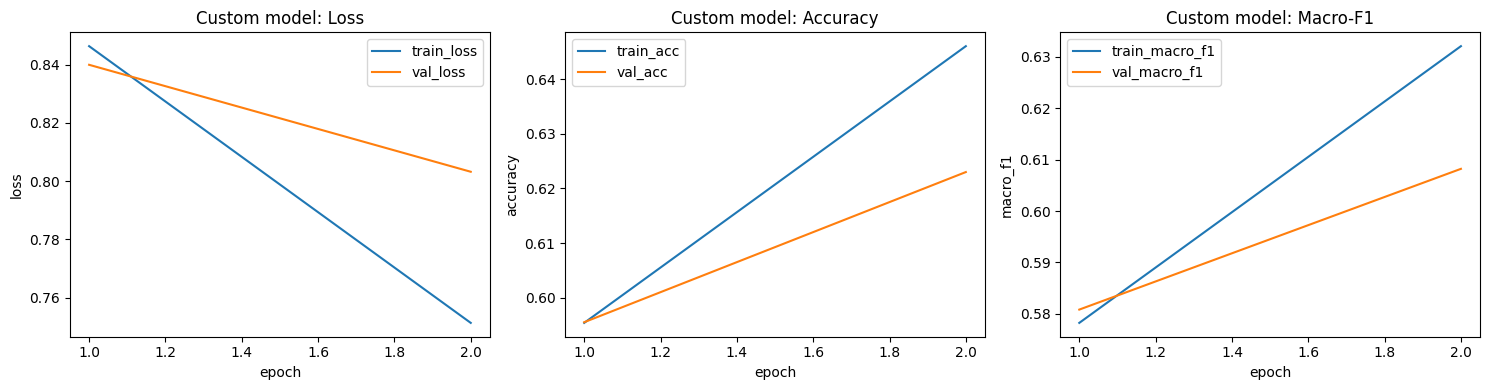

In [7]:
'''
БЛОК 5A. ОБУЧЕНИЕ СОБСТВЕННОГО ENCODER-ONLY TRANSFORMER
(TRAIN/VAL ЦИКЛ, METRICS, EARLY STOPPING, СОХРАНЕНИЕ ЛУЧШИХ ВЕСОВ)

Что делает этот блок:
1) Настраивает функцию потерь и оптимизатор для собственной модели.
2) Учитывает дисбаланс классов через class weights в CrossEntropyLoss.
3) Запускает цикл обучения по эпохам:
   - train phase (с градиентами),
   - val phase (без градиентов).
4) Считает метрики:
   - loss,
   - accuracy,
   - macro-F1.
5) Сохраняет лучший checkpoint по val_macro_f1.
6) Использует early stopping, чтобы остановить обучение при отсутствии улучшений.
7) Строит графики кривых обучения для отчёта.

Почему это важно:
- Macro-F1 ключевая метрика при сдвиге/дисбалансе классов.
- Early stopping уменьшает риск переобучения.
- Лучший checkpoint нужен для честной финальной оценки на test.
'''

import time  # Импортируем модуль времени для замера длительности эпох.
import copy  # Импортируем copy для хранения лучшего состояния модели (state_dict).

def compute_class_weights(labels_tensor, num_classes):  # Объявляем функцию вычисления весов классов для дисбаланса.
    counts = torch.bincount(labels_tensor, minlength=num_classes).float()  # Считаем количество объектов каждого класса.
    total = counts.sum()  # Считаем общее число объектов.
    weights = total / (num_classes * counts.clamp(min=1.0))  # Вычисляем обратнопропорциональные веса классов.
    weights = weights / weights.mean()  # Нормируем веса так, чтобы средний вес был равен 1.
    return weights  # Возвращаем вектор весов классов.

class_weights = compute_class_weights(y_train_t, NUM_CLASSES).to(device)  # Вычисляем и переносим веса классов на устройство.
print("Class weights:", class_weights.detach().cpu().numpy())  # Печатаем веса классов для контроля.

criterion_custom = nn.CrossEntropyLoss(weight=class_weights)  # Создаем функцию потерь с учетом дисбаланса классов.
optimizer_custom = torch.optim.AdamW(model_custom.parameters(), lr=LR_CUSTOM, weight_decay=1e-4)  # Создаем оптимизатор AdamW для обучения своей модели.

def train_one_epoch_custom(model, loader, criterion, optimizer, dev):  # Объявляем функцию обучения модели за одну эпоху.
    model.train()  # Переводим модель в режим обучения.
    running_loss = 0.0  # Инициализируем накопитель loss по батчам.
    y_true_all = []  # Инициализируем список истинных меток для метрик эпохи.
    y_pred_all = []  # Инициализируем список предсказанных меток для метрик эпохи.

    for batch in loader:  # Идем по всем батчам train_loader.
        input_ids = batch["input_ids"].to(dev)  # Переносим input_ids текущего батча на устройство.
        attention_mask = batch["attention_mask"].to(dev)  # Переносим attention_mask текущего батча на устройство.
        labels = batch["labels"].to(dev)  # Переносим labels текущего батча на устройство.

        optimizer.zero_grad()  # Обнуляем градиенты перед новым шагом оптимизации.
        logits = model(input_ids=input_ids, attention_mask=attention_mask)  # Выполняем прямой проход модели.
        loss = criterion(logits, labels)  # Вычисляем loss батча по logits и истинным меткам.
        loss.backward()  # Считаем градиенты всех параметров модели.
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Ограничиваем норму градиента для стабильности.
        optimizer.step()  # Обновляем параметры модели шагом оптимизатора.

        running_loss += loss.item() * labels.size(0)  # Накопливаем суммарный loss с учетом размера батча.
        preds = torch.argmax(logits, dim=1)  # Преобразуем logits в предсказанные классы.
        y_true_all.extend(labels.detach().cpu().tolist())  # Добавляем истинные метки батча в общий список.
        y_pred_all.extend(preds.detach().cpu().tolist())  # Добавляем предсказанные метки батча в общий список.

    epoch_loss = running_loss / len(loader.dataset)  # Вычисляем средний loss на всей train-выборке.
    epoch_acc = accuracy_score(y_true_all, y_pred_all)  # Вычисляем accuracy на train за эпоху.
    epoch_f1 = f1_score(y_true_all, y_pred_all, average="macro")  # Вычисляем macro-F1 на train за эпоху.
    return epoch_loss, epoch_acc, epoch_f1  # Возвращаем три метрики train-эпохи.

@torch.no_grad()  # Отключаем вычисление градиентов для фазы оценки.
def evaluate_custom(model, loader, criterion, dev):  # Объявляем функцию оценки модели на val/test.
    model.eval()  # Переводим модель в режим оценки.
    running_loss = 0.0  # Инициализируем накопитель loss по батчам.
    y_true_all = []  # Инициализируем список истинных меток для метрик.
    y_pred_all = []  # Инициализируем список предсказаний для метрик.

    for batch in loader:  # Идем по батчам val_loader или test_loader.
        input_ids = batch["input_ids"].to(dev)  # Переносим input_ids батча на устройство.
        attention_mask = batch["attention_mask"].to(dev)  # Переносим attention_mask батча на устройство.
        labels = batch["labels"].to(dev)  # Переносим labels батча на устройство.

        logits = model(input_ids=input_ids, attention_mask=attention_mask)  # Выполняем прямой проход модели.
        loss = criterion(logits, labels)  # Вычисляем loss батча.
        running_loss += loss.item() * labels.size(0)  # Накопливаем суммарный loss с учетом размера батча.

        preds = torch.argmax(logits, dim=1)  # Получаем классы с максимальным логитом.
        y_true_all.extend(labels.detach().cpu().tolist())  # Добавляем истинные метки в общий список.
        y_pred_all.extend(preds.detach().cpu().tolist())  # Добавляем предсказанные метки в общий список.

    epoch_loss = running_loss / len(loader.dataset)  # Вычисляем средний loss на всей выборке.
    epoch_acc = accuracy_score(y_true_all, y_pred_all)  # Вычисляем accuracy на всей выборке.
    epoch_f1 = f1_score(y_true_all, y_pred_all, average="macro")  # Вычисляем macro-F1 на всей выборке.
    return epoch_loss, epoch_acc, epoch_f1  # Возвращаем метрики оценки.

history_custom = {  # Создаем словарь для хранения истории метрик по эпохам.
    "train_loss": [],  # Список train loss по эпохам.
    "train_acc": [],  # Список train accuracy по эпохам.
    "train_f1": [],  # Список train macro-F1 по эпохам.
    "val_loss": [],  # Список val loss по эпохам.
    "val_acc": [],  # Список val accuracy по эпохам.
    "val_f1": [],  # Список val macro-F1 по эпохам.
}  # Закрываем словарь истории.

best_val_f1 = -1.0  # Инициализируем лучшее значение val macro-F1.
best_epoch = -1  # Инициализируем номер лучшей эпохи.
best_state = None  # Инициализируем хранилище для лучшего состояния модели.
epochs_without_improve = 0  # Счетчик эпох без улучшения val macro-F1.
ckpt_custom_path = SAVE_DIR / "lab4_custom_encoder_best.pt"  # Формируем путь для сохранения лучшего checkpoint своей модели.

print("\nСтарт обучения собственной модели...")  # Печатаем сообщение о начале обучения.
for epoch in range(1, EPOCHS_CUSTOM + 1):  # Запускаем цикл по эпохам от 1 до EPOCHS_CUSTOM.
    t0 = time.time()  # Фиксируем время начала текущей эпохи.
    tr_loss, tr_acc, tr_f1 = train_one_epoch_custom(model_custom, train_loader_custom, criterion_custom, optimizer_custom, device)  # Обучаем одну train-эпоху.
    va_loss, va_acc, va_f1 = evaluate_custom(model_custom, val_loader_custom, criterion_custom, device)  # Оцениваем модель на validation после эпохи.
    epoch_sec = time.time() - t0  # Вычисляем длительность эпохи в секундах.

    history_custom["train_loss"].append(tr_loss)  # Сохраняем train loss текущей эпохи.
    history_custom["train_acc"].append(tr_acc)  # Сохраняем train accuracy текущей эпохи.
    history_custom["train_f1"].append(tr_f1)  # Сохраняем train macro-F1 текущей эпохи.
    history_custom["val_loss"].append(va_loss)  # Сохраняем val loss текущей эпохи.
    history_custom["val_acc"].append(va_acc)  # Сохраняем val accuracy текущей эпохи.
    history_custom["val_f1"].append(va_f1)  # Сохраняем val macro-F1 текущей эпохи.

    print(  # Печатаем строку-лог с ключевыми метриками эпохи.
        f"Epoch {epoch:02d}/{EPOCHS_CUSTOM} | "  # Выводим номер эпохи и общее число эпох.
        f"train_loss={tr_loss:.4f} acc={tr_acc:.4f} f1={tr_f1:.4f} | "  # Выводим train-метрики.
        f"val_loss={va_loss:.4f} acc={va_acc:.4f} f1={va_f1:.4f} | "  # Выводим val-метрики.
        f"time={epoch_sec:.1f}s"  # Выводим время эпохи.
    )  # Закрываем print.

    if va_f1 > best_val_f1:  # Проверяем, улучшился ли val macro-F1.
        best_val_f1 = va_f1  # Обновляем лучшее значение val macro-F1.
        best_epoch = epoch  # Сохраняем номер лучшей эпохи.
        best_state = copy.deepcopy(model_custom.state_dict())  # Делаем глубокую копию текущих лучших весов.
        torch.save(best_state, ckpt_custom_path)  # Сохраняем лучший checkpoint на диск.
        epochs_without_improve = 0  # Сбрасываем счетчик эпох без улучшения.
    else:  # Ветка, когда улучшения val macro-F1 нет.
        epochs_without_improve += 1  # Увеличиваем счетчик эпох без улучшения.
        if epochs_without_improve >= PATIENCE:  # Проверяем условие early stopping.
            print(f"Early stopping: нет улучшения val_macro_f1 {PATIENCE} эпох подряд.")  # Сообщаем о досрочной остановке обучения.
            break  # Прерываем цикл эпох.

if best_state is not None:  # Проверяем, что лучшая модель действительно была сохранена.
    model_custom.load_state_dict(best_state)  # Загружаем в модель лучшие веса по val macro-F1.
print(f"\nЛучшая эпоха: {best_epoch}, лучший val_macro_f1: {best_val_f1:.4f}")  # Печатаем итог лучшей эпохи и лучшей метрики.
print(f"Лучший checkpoint сохранен: {ckpt_custom_path}")  # Печатаем путь к сохраненному лучшему checkpoint.

epochs_axis = list(range(1, len(history_custom["train_loss"]) + 1))  # Формируем ось эпох для графиков.
plt.figure(figsize=(15, 4))  # Создаем общий рисунок для трех графиков.
plt.subplot(1, 3, 1)  # Выбираем первый подграфик для loss.
plt.plot(epochs_axis, history_custom["train_loss"], label="train_loss")  # Рисуем кривую train loss.
plt.plot(epochs_axis, history_custom["val_loss"], label="val_loss")  # Рисуем кривую val loss.
plt.xlabel("epoch")  # Подписываем ось X.
plt.ylabel("loss")  # Подписываем ось Y.
plt.title("Custom model: Loss")  # Добавляем заголовок графика loss.
plt.legend()  # Показываем легенду графика.

plt.subplot(1, 3, 2)  # Выбираем второй подграфик для accuracy.
plt.plot(epochs_axis, history_custom["train_acc"], label="train_acc")  # Рисуем кривую train accuracy.
plt.plot(epochs_axis, history_custom["val_acc"], label="val_acc")  # Рисуем кривую val accuracy.
plt.xlabel("epoch")  # Подписываем ось X.
plt.ylabel("accuracy")  # Подписываем ось Y.
plt.title("Custom model: Accuracy")  # Добавляем заголовок графика accuracy.
plt.legend()  # Показываем легенду графика.

plt.subplot(1, 3, 3)  # Выбираем третий подграфик для macro-F1.
plt.plot(epochs_axis, history_custom["train_f1"], label="train_macro_f1")  # Рисуем кривую train macro-F1.
plt.plot(epochs_axis, history_custom["val_f1"], label="val_macro_f1")  # Рисуем кривую val macro-F1.
plt.xlabel("epoch")  # Подписываем ось X.
plt.ylabel("macro_f1")  # Подписываем ось Y.
plt.title("Custom model: Macro-F1")  # Добавляем заголовок графика macro-F1.
plt.legend()  # Показываем легенду графика.

plt.tight_layout()  # Автоматически корректируем отступы между графиками.
plt.show()  # Отображаем графики истории обучения.

FAST train size: 10000 | val size: 2000 | test size: 12284


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Старт ускоренного fine-tuning DistilBERT...
[TRAIN] step 200/1250 | elapsed=260.6s | last_loss=0.7944
[TRAIN] step 400/1250 | elapsed=529.6s | last_loss=1.1089
[TRAIN] step 600/1250 | elapsed=789.2s | last_loss=0.4623
[TRAIN] step 800/1250 | elapsed=1048.6s | last_loss=0.8020
[TRAIN] step 1000/1250 | elapsed=1308.0s | last_loss=0.8687
[TRAIN] step 1200/1250 | elapsed=1567.0s | last_loss=2.4072
[TRAIN] step 1250/1250 | elapsed=1631.6s | last_loss=0.8348
Epoch 01/1 | train_loss=0.7936 acc=0.6378 f1=0.6223 | val_loss=0.7502 acc=0.6850 f1=0.6675 | time=1697.1s

Лучшая эпоха fast DistilBERT: 1, лучший val_macro_f1: 0.6675
Сохранен fast checkpoint: d:\6_семестр\Машинное обучение и большие данные\лаб2\lab4_checkpoints\lab4_distilbert_fast_best.pt


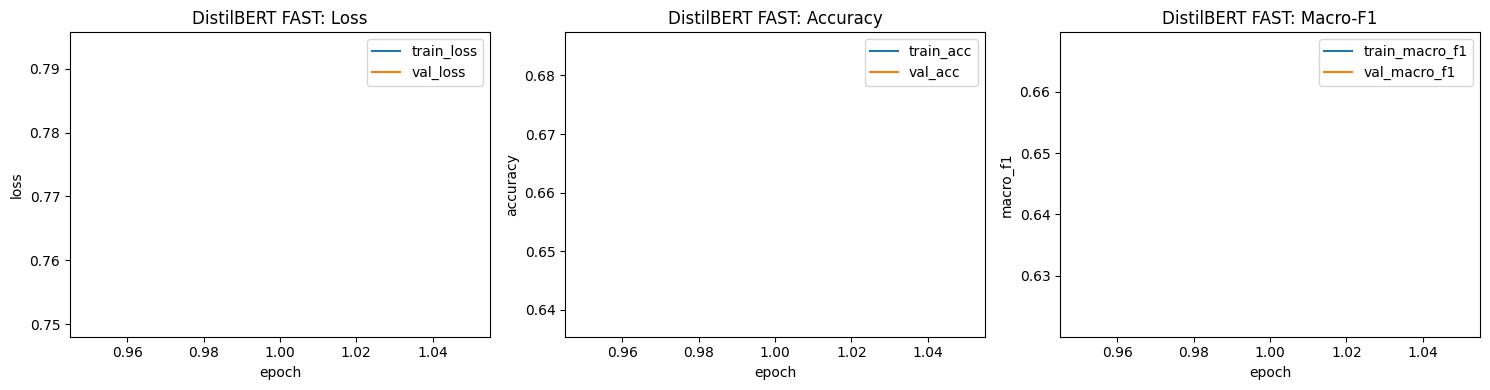

In [9]:
'''
БЛОК 5B (FAST CPU). УСКОРЕННЫЙ FINE-TUNING DISTILBERT С ПЕЧАТЬЮ ПРОГРЕССА ПО БАТЧАМ

Что делает этот блок:
1) Берет подмножество train, чтобы резко сократить время обучения на CPU.
2) Токенизирует данные для DistilBERT с более короткой длиной последовательности (MAX_LEN_BERT_FAST=64).
3) Создает отдельные DataLoader для быстрого режима.
4) Загружает DistilBERT для классификации на 3 класса.
5) Обучает 1 эпоху с печатью прогресса каждые N батчей.
6) Считает val метрики (loss/accuracy/macro-F1), сохраняет best checkpoint.
7) Строит компактные графики итогов (даже при 1 эпохе).

Почему это быстро:
- меньше train-примеров,
- короче последовательности (attention дешевле),
- минимум эпох,
- без лишних сетевых повторных загрузок.
'''

import time  # Импортируем time для замера длительности обучения.
import copy  # Импортируем copy для сохранения лучшего состояния модели.
import torch  # Импортируем PyTorch.
import torch.nn as nn  # Импортируем нейросетевые слои.
from torch.utils.data import Dataset, DataLoader  # Импортируем Dataset/DataLoader.
from sklearn.metrics import accuracy_score, f1_score  # Импортируем метрики accuracy и macro-F1.
from transformers import AutoTokenizer, AutoModelForSequenceClassification  # Импортируем токенизатор и модель DistilBERT.

# ---------------- FAST CONFIG ----------------
TRAIN_SUBSET_SIZE = 10000  # Размер подмножества train для ускоренного режима.
MAX_LEN_BERT_FAST = 64  # Укороченная длина последовательности для ускорения self-attention.
BATCH_SIZE_BERT_FAST = 8  # Небольшой батч для стабильной работы на CPU.
EPOCHS_BERT_FAST = 1  # Минимум эпох для быстрого валидного прогона.
LR_BERT_FAST = 2e-5  # Стандартный learning rate для fine-tuning BERT-подобных моделей.
PRINT_EVERY = 200  # Частота печати прогресса в train-цикле (каждые N батчей).

# ---------------- DATA PREP (FAST SUBSET) ----------------
train_df_bert = train_df.sample(n=min(TRAIN_SUBSET_SIZE, len(train_df)), random_state=SEED).reset_index(drop=True)  # Берем случайное подмножество train.
val_df_bert = val_df.copy()  # Берем полную validation-выборку для честной оценки.
test_df_bert = test_df.copy()  # Берем полную test-выборку для финальной оценки после обучения.

print(f"FAST train size: {len(train_df_bert)} | val size: {len(val_df_bert)} | test size: {len(test_df_bert)}")  # Печатаем размеры fast-выборок.

tokenizer_fast = AutoTokenizer.from_pretrained(MODEL_NAME)  # Загружаем токенизатор DistilBERT.

def tokenize_for_bert_fast(texts, tokenizer, max_len):  # Объявляем функцию токенизации списка текстов для fast-режима.
    enc = tokenizer(  # Токенизируем входной список строк.
        texts,  # Передаем список текстов.
        padding="max_length",  # Дополняем до фиксированной длины max_len.
        truncation=True,  # Обрезаем слишком длинные тексты.
        max_length=max_len,  # Задаем максимальную длину последовательности.
        return_tensors="pt",  # Возвращаем результат как PyTorch-тензоры.
    )  # Закрываем вызов токенизатора.
    return enc["input_ids"], enc["attention_mask"]  # Возвращаем input_ids и attention_mask.

X_train_ids_fast, X_train_mask_fast = tokenize_for_bert_fast(train_df_bert["text"].astype(str).tolist(), tokenizer_fast, MAX_LEN_BERT_FAST)  # Токенизируем fast-train.
X_val_ids_fast, X_val_mask_fast = tokenize_for_bert_fast(val_df_bert["text"].astype(str).tolist(), tokenizer_fast, MAX_LEN_BERT_FAST)  # Токенизируем val.
X_test_ids_fast, X_test_mask_fast = tokenize_for_bert_fast(test_df_bert["text"].astype(str).tolist(), tokenizer_fast, MAX_LEN_BERT_FAST)  # Токенизируем test.

y_train_fast = torch.tensor(train_df_bert["label"].tolist(), dtype=torch.long)  # Преобразуем метки train в тензор long.
y_val_fast = torch.tensor(val_df_bert["label"].tolist(), dtype=torch.long)  # Преобразуем метки val в тензор long.
y_test_fast = torch.tensor(test_df_bert["label"].tolist(), dtype=torch.long)  # Преобразуем метки test в тензор long.

class BertFastDataset(Dataset):  # Объявляем Dataset-класс для fast DistilBERT.
    def __init__(self, input_ids, attention_mask, labels):  # Конструктор принимает тензоры входов и меток.
        self.input_ids = input_ids  # Сохраняем input_ids.
        self.attention_mask = attention_mask  # Сохраняем attention_mask.
        self.labels = labels  # Сохраняем labels.
    def __len__(self):  # Метод длины датасета.
        return self.labels.size(0)  # Возвращаем число объектов.
    def __getitem__(self, idx):  # Метод получения одного объекта по индексу.
        return {  # Возвращаем словарь полей одного примера.
            "input_ids": self.input_ids[idx],  # Токен-индексы.
            "attention_mask": self.attention_mask[idx],  # Маска внимания.
            "labels": self.labels[idx],  # Метка класса.
        }  # Закрываем словарь.

train_ds_fast = BertFastDataset(X_train_ids_fast, X_train_mask_fast, y_train_fast)  # Создаем fast train Dataset.
val_ds_fast = BertFastDataset(X_val_ids_fast, X_val_mask_fast, y_val_fast)  # Создаем val Dataset.
test_ds_fast = BertFastDataset(X_test_ids_fast, X_test_mask_fast, y_test_fast)  # Создаем test Dataset.

train_loader_fast = DataLoader(train_ds_fast, batch_size=BATCH_SIZE_BERT_FAST, shuffle=True)  # Создаем train DataLoader с перемешиванием.
val_loader_fast = DataLoader(val_ds_fast, batch_size=BATCH_SIZE_BERT_FAST, shuffle=False)  # Создаем val DataLoader без перемешивания.
test_loader_fast = DataLoader(test_ds_fast, batch_size=BATCH_SIZE_BERT_FAST, shuffle=False)  # Создаем test DataLoader без перемешивания.

# ---------------- MODEL ----------------
model_bert_fast = AutoModelForSequenceClassification.from_pretrained(  # Загружаем DistilBERT-классификатор.
    MODEL_NAME,  # Передаем имя модели.
    num_labels=NUM_CLASSES,  # Указываем число классов.
    ignore_mismatched_sizes=True,  # Разрешаем переинициализацию classification-головы.
).to(device)  # Переносим модель на устройство.

criterion_fast = nn.CrossEntropyLoss(weight=class_weights)  # Создаем weighted loss для учета дисбаланса классов.
optimizer_fast = torch.optim.AdamW(model_bert_fast.parameters(), lr=LR_BERT_FAST, weight_decay=1e-2)  # Создаем AdamW оптимизатор.

def train_one_epoch_bert_fast(model, loader, criterion, optimizer, dev, print_every=200):  # Объявляем train-функцию на одну эпоху с печатью прогресса.
    model.train()  # Включаем режим обучения.
    running_loss = 0.0  # Инициализируем накопитель loss.
    y_true_all = []  # Инициализируем список истинных меток.
    y_pred_all = []  # Инициализируем список предсказаний.
    t_start = time.time()  # Запоминаем время старта эпохи.

    for step, batch in enumerate(loader, 1):  # Идем по батчам с нумерацией от 1.
        input_ids = batch["input_ids"].to(dev)  # Переносим input_ids батча на устройство.
        attention_mask = batch["attention_mask"].to(dev)  # Переносим attention_mask батча на устройство.
        labels = batch["labels"].to(dev)  # Переносим labels батча на устройство.

        optimizer.zero_grad(set_to_none=True)  # Обнуляем градиенты перед backward.
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)  # Выполняем forward-pass.
        logits = outputs.logits  # Извлекаем logits классов.
        loss = criterion(logits, labels)  # Считаем loss батча.

        if not torch.isfinite(loss):  # Проверяем loss на NaN/Inf.
            print(f"[WARN] step {step}: non-finite loss, skip batch")  # Печатаем предупреждение о пропуске батча.
            continue  # Пропускаем шаг оптимизации для этого батча.

        loss.backward()  # Вычисляем градиенты.
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Ограничиваем норму градиентов.
        optimizer.step()  # Обновляем параметры модели.

        running_loss += loss.item() * labels.size(0)  # Накопливаем суммарный loss с учетом размера батча.
        preds = torch.argmax(logits, dim=1)  # Получаем предсказанные классы.
        y_true_all.extend(labels.detach().cpu().tolist())  # Добавляем истинные метки в общий список.
        y_pred_all.extend(preds.detach().cpu().tolist())  # Добавляем предсказания в общий список.

        if step % print_every == 0 or step == len(loader):  # Проверяем, пора ли печатать прогресс.
            elapsed = time.time() - t_start  # Считаем прошедшее время с начала эпохи.
            print(f"[TRAIN] step {step}/{len(loader)} | elapsed={elapsed:.1f}s | last_loss={loss.item():.4f}")  # Печатаем прогресс батчей.

    epoch_loss = running_loss / len(loader.dataset)  # Считаем средний train loss по всей выборке.
    epoch_acc = accuracy_score(y_true_all, y_pred_all) if len(y_true_all) > 0 else 0.0  # Считаем train accuracy.
    epoch_f1 = f1_score(y_true_all, y_pred_all, average="macro", zero_division=0) if len(y_true_all) > 0 else 0.0  # Считаем train macro-F1.
    return epoch_loss, epoch_acc, epoch_f1  # Возвращаем train-метрики эпохи.

@torch.no_grad()  # Выключаем градиенты для фазы оценки.
def evaluate_bert_fast(model, loader, criterion, dev):  # Объявляем функцию валидации/теста.
    model.eval()  # Включаем режим оценки.
    running_loss = 0.0  # Инициализируем накопитель loss.
    y_true_all = []  # Инициализируем список истинных меток.
    y_pred_all = []  # Инициализируем список предсказаний.

    for batch in loader:  # Идем по батчам val/test.
        input_ids = batch["input_ids"].to(dev)  # Переносим input_ids на устройство.
        attention_mask = batch["attention_mask"].to(dev)  # Переносим attention_mask на устройство.
        labels = batch["labels"].to(dev)  # Переносим labels на устройство.

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)  # Выполняем forward-pass.
        logits = outputs.logits  # Извлекаем logits.
        loss = criterion(logits, labels)  # Считаем loss.
        running_loss += loss.item() * labels.size(0)  # Накопливаем суммарный loss.

        preds = torch.argmax(logits, dim=1)  # Получаем предсказанные классы.
        y_true_all.extend(labels.detach().cpu().tolist())  # Добавляем истинные метки.
        y_pred_all.extend(preds.detach().cpu().tolist())  # Добавляем предсказания.

    epoch_loss = running_loss / len(loader.dataset)  # Считаем средний loss на выборке.
    epoch_acc = accuracy_score(y_true_all, y_pred_all)  # Считаем accuracy на выборке.
    epoch_f1 = f1_score(y_true_all, y_pred_all, average="macro", zero_division=0)  # Считаем macro-F1 на выборке.
    return epoch_loss, epoch_acc, epoch_f1  # Возвращаем метрики оценки.

history_bert_fast = {  # Создаем словарь истории метрик fast DistilBERT.
    "train_loss": [],  # Список train loss.
    "train_acc": [],  # Список train accuracy.
    "train_f1": [],  # Список train macro-F1.
    "val_loss": [],  # Список val loss.
    "val_acc": [],  # Список val accuracy.
    "val_f1": [],  # Список val macro-F1.
}  # Закрываем словарь.

best_val_f1_fast = -1.0  # Инициализируем лучшее значение val macro-F1.
best_epoch_fast = -1  # Инициализируем номер лучшей эпохи.
best_state_fast = None  # Инициализируем хранилище лучшего состояния модели.
ckpt_bert_fast_path = SAVE_DIR / "lab4_distilbert_fast_best.pt"  # Формируем путь для fast checkpoint.

print("\nСтарт ускоренного fine-tuning DistilBERT...")  # Печатаем сообщение о старте обучения.
for epoch in range(1, EPOCHS_BERT_FAST + 1):  # Запускаем цикл эпох fast DistilBERT.
    t0 = time.time()  # Запоминаем время начала эпохи.
    tr_loss, tr_acc, tr_f1 = train_one_epoch_bert_fast(model_bert_fast, train_loader_fast, criterion_fast, optimizer_fast, device, print_every=PRINT_EVERY)  # Обучаем одну эпоху.
    va_loss, va_acc, va_f1 = evaluate_bert_fast(model_bert_fast, val_loader_fast, criterion_fast, device)  # Оцениваем на validation.
    epoch_sec = time.time() - t0  # Считаем длительность эпохи.

    history_bert_fast["train_loss"].append(tr_loss)  # Сохраняем train loss.
    history_bert_fast["train_acc"].append(tr_acc)  # Сохраняем train accuracy.
    history_bert_fast["train_f1"].append(tr_f1)  # Сохраняем train macro-F1.
    history_bert_fast["val_loss"].append(va_loss)  # Сохраняем val loss.
    history_bert_fast["val_acc"].append(va_acc)  # Сохраняем val accuracy.
    history_bert_fast["val_f1"].append(va_f1)  # Сохраняем val macro-F1.

    print(  # Печатаем строку итогов эпохи.
        f"Epoch {epoch:02d}/{EPOCHS_BERT_FAST} | "  # Номер эпохи.
        f"train_loss={tr_loss:.4f} acc={tr_acc:.4f} f1={tr_f1:.4f} | "  # Train-метрики.
        f"val_loss={va_loss:.4f} acc={va_acc:.4f} f1={va_f1:.4f} | "  # Val-метрики.
        f"time={epoch_sec:.1f}s"  # Время эпохи.
    )  # Закрываем print.

    if va_f1 > best_val_f1_fast:  # Проверяем улучшение по val macro-F1.
        best_val_f1_fast = va_f1  # Обновляем лучший val macro-F1.
        best_epoch_fast = epoch  # Запоминаем лучшую эпоху.
        best_state_fast = copy.deepcopy(model_bert_fast.state_dict())  # Копируем лучший state_dict.
        torch.save(best_state_fast, ckpt_bert_fast_path)  # Сохраняем лучший checkpoint на диск.

if best_state_fast is not None:  # Проверяем, что лучший checkpoint найден.
    model_bert_fast.load_state_dict(best_state_fast)  # Загружаем лучшие веса обратно в модель.
print(f"\nЛучшая эпоха fast DistilBERT: {best_epoch_fast}, лучший val_macro_f1: {best_val_f1_fast:.4f}")  # Печатаем итог лучшей эпохи.
print(f"Сохранен fast checkpoint: {ckpt_bert_fast_path}")  # Печатаем путь к сохраненному checkpoint.

epochs_axis_fast = list(range(1, len(history_bert_fast["train_loss"]) + 1))  # Формируем ось эпох для графиков.
plt.figure(figsize=(15, 4))  # Создаем фигуру для трех графиков.
plt.subplot(1, 3, 1)  # Выбираем график loss.
plt.plot(epochs_axis_fast, history_bert_fast["train_loss"], label="train_loss")  # Рисуем train loss.
plt.plot(epochs_axis_fast, history_bert_fast["val_loss"], label="val_loss")  # Рисуем val loss.
plt.xlabel("epoch")  # Подписываем ось X.
plt.ylabel("loss")  # Подписываем ось Y.
plt.title("DistilBERT FAST: Loss")  # Ставим заголовок графика loss.
plt.legend()  # Показываем легенду графика.

plt.subplot(1, 3, 2)  # Выбираем график accuracy.
plt.plot(epochs_axis_fast, history_bert_fast["train_acc"], label="train_acc")  # Рисуем train accuracy.
plt.plot(epochs_axis_fast, history_bert_fast["val_acc"], label="val_acc")  # Рисуем val accuracy.
plt.xlabel("epoch")  # Подписываем ось X.
plt.ylabel("accuracy")  # Подписываем ось Y.
plt.title("DistilBERT FAST: Accuracy")  # Ставим заголовок графика accuracy.
plt.legend()  # Показываем легенду графика.

plt.subplot(1, 3, 3)  # Выбираем график macro-F1.
plt.plot(epochs_axis_fast, history_bert_fast["train_f1"], label="train_macro_f1")  # Рисуем train macro-F1.
plt.plot(epochs_axis_fast, history_bert_fast["val_f1"], label="val_macro_f1")  # Рисуем val macro-F1.
plt.xlabel("epoch")  # Подписываем ось X.
plt.ylabel("macro_f1")  # Подписываем ось Y.
plt.title("DistilBERT FAST: Macro-F1")  # Ставим заголовок графика macro-F1.
plt.legend()  # Показываем легенду графика.

plt.tight_layout()  # Делаем аккуратные отступы между графиками.
plt.show()  # Отображаем графики.

[LOAD] custom checkpoint loaded: d:\6_семестр\Машинное обучение и большие данные\лаб2\lab4_checkpoints\lab4_custom_encoder_best.pt
[LOAD] distilbert fast checkpoint loaded: d:\6_семестр\Машинное обучение и большие данные\лаб2\lab4_checkpoints\lab4_distilbert_fast_best.pt

=== CUSTOM ENCODER-ONLY (TEST) ===
{'accuracy': 0.595, 'macro_f1': 0.5886, 'weighted_f1': 0.5941, 'macro_precision': 0.5928, 'macro_recall': 0.5949}

Classification report (custom):
              precision    recall  f1-score   support

           0     0.5420    0.7002    0.6110      3972
           1     0.6566    0.5481    0.5974      5937
           2     0.5799    0.5364    0.5573      2375

    accuracy                         0.5950     12284
   macro avg     0.5928    0.5949    0.5886     12284
weighted avg     0.6047    0.5950    0.5941     12284


=== DISTILBERT (TEST) ===
{'accuracy': 0.6585, 'macro_f1': 0.6574, 'weighted_f1': 0.6567, 'macro_precision': 0.6489, 'macro_recall': 0.6853}

Classification report

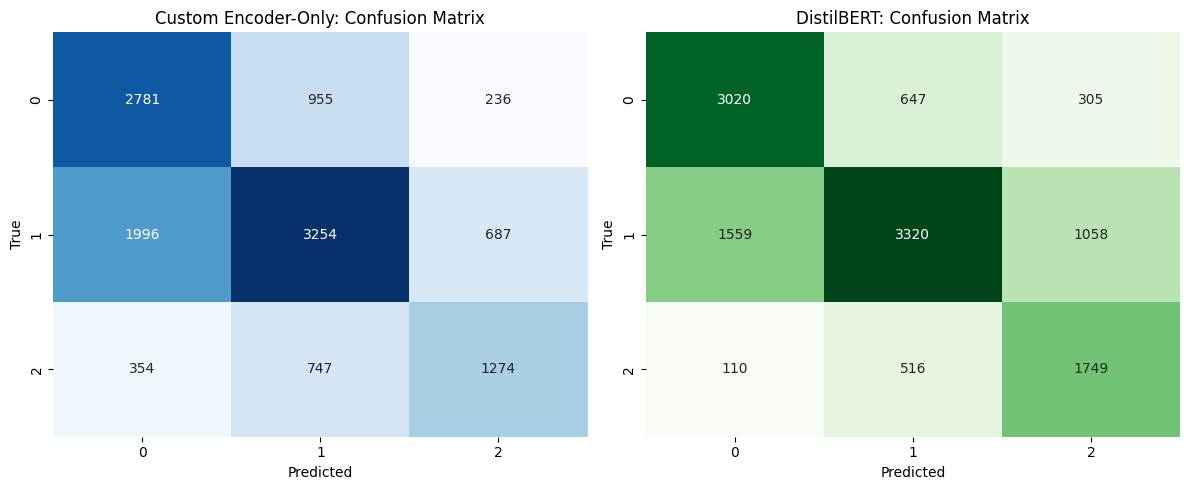


=== ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ (TEST) ===


,model,test_accuracy,test_macro_f1,test_weighted_f1,test_macro_precision,test_macro_recall
0,Custom Encoder-Only,0.5950,0.5886,0.5941,0.5928,0.5949
1,DistilBERT,0.6585,0.6574,0.6567,0.6489,0.6853



Лидер по test_macro_f1: DistilBERT


In [10]:
'''
БЛОК 6. ФИНАЛЬНАЯ ОЦЕНКА НА TEST И СРАВНЕНИЕ ДВУХ МОДЕЛЕЙ

Что делает этот блок:
1) Загружает лучшие веса своей модели и DistilBERT (если они сохранены).
2) Запускает предсказания на test для обеих моделей.
3) Считает метрики:
   - accuracy,
   - macro-F1,
   - weighted-F1.
4) Печатает classification_report (precision/recall/F1 по каждому классу).
5) Строит confusion matrix для обеих моделей.
6) Формирует итоговую таблицу сравнения для отчёта.

Почему это важно:
- Это ключевая цель ЛР4: честно сравнить свою модель и предобученную.
- При дисбалансе классов особенно важен macro-F1, а не только accuracy.
'''

from sklearn.metrics import precision_recall_fscore_support  # Импортируем функцию для расчета precision/recall/F1.
import numpy as np  # Импортируем NumPy для удобной работы с массивами метрик.

# ---------------- OPTIONAL: SAFE LOAD BEST CHECKPOINTS ----------------
if 'ckpt_custom_path' in globals() and Path(ckpt_custom_path).exists():  # Проверяем, существует ли путь к лучшему чекпоинту своей модели.
    model_custom.load_state_dict(torch.load(ckpt_custom_path, map_location=device))  # Загружаем лучшие веса своей модели с диска.
    print(f"[LOAD] custom checkpoint loaded: {ckpt_custom_path}")  # Печатаем подтверждение загрузки своей модели.
else:  # Ветка, если чекпоинт своей модели не найден.
    print("[WARN] custom checkpoint not found, используем текущие веса model_custom")  # Печатаем предупреждение о текущих весах своей модели.

if 'ckpt_bert_fast_path' in globals() and Path(ckpt_bert_fast_path).exists():  # Проверяем, существует ли путь к лучшему fast-чекпоинту DistilBERT.
    model_bert_fast.load_state_dict(torch.load(ckpt_bert_fast_path, map_location=device))  # Загружаем лучшие веса DistilBERT fast с диска.
    print(f"[LOAD] distilbert fast checkpoint loaded: {ckpt_bert_fast_path}")  # Печатаем подтверждение загрузки DistilBERT fast.
elif 'ckpt_bert_path' in globals() and Path(ckpt_bert_path).exists():  # Проверяем альтернативный путь к чекпоинту DistilBERT (не-fast версия).
    model_bert.load_state_dict(torch.load(ckpt_bert_path, map_location=device))  # Загружаем лучшие веса DistilBERT из обычного пути.
    print(f"[LOAD] distilbert checkpoint loaded: {ckpt_bert_path}")  # Печатаем подтверждение загрузки обычного DistilBERT.
else:  # Ветка, если DistilBERT-чекпоинт не найден.
    print("[WARN] distilbert checkpoint not found, используем текущие веса DistilBERT модели")  # Печатаем предупреждение о текущих весах DistilBERT.

# ---------------- GENERIC EVAL FUNCTION ----------------
@torch.no_grad()  # Отключаем вычисление градиентов для режима инференса.
def predict_custom(model, loader, dev):  # Объявляем функцию предсказания для своей модели.
    model.eval()  # Переводим свою модель в eval-режим.
    y_true, y_pred = [], []  # Инициализируем списки истинных и предсказанных меток.
    for batch in loader:  # Идем по батчам test_loader_custom.
        input_ids = batch["input_ids"].to(dev)  # Переносим input_ids батча на устройство.
        attention_mask = batch["attention_mask"].to(dev)  # Переносим attention_mask батча на устройство.
        labels = batch["labels"].to(dev)  # Переносим labels батча на устройство.
        logits = model(input_ids=input_ids, attention_mask=attention_mask)  # Получаем logits своей модели.
        preds = torch.argmax(logits, dim=1)  # Получаем предсказанные классы argmax-операцией.
        y_true.extend(labels.cpu().tolist())  # Добавляем истинные метки батча в общий список.
        y_pred.extend(preds.cpu().tolist())  # Добавляем предсказанные метки батча в общий список.
    return y_true, y_pred  # Возвращаем списки y_true и y_pred для своей модели.

@torch.no_grad()  # Отключаем вычисление градиентов для режима инференса.
def predict_bert(model, loader, dev):  # Объявляем функцию предсказания для DistilBERT.
    model.eval()  # Переводим DistilBERT в eval-режим.
    y_true, y_pred = [], []  # Инициализируем списки истинных и предсказанных меток.
    for batch in loader:  # Идем по батчам test_loader_fast (или другого BERT-loader).
        input_ids = batch["input_ids"].to(dev)  # Переносим input_ids на устройство.
        attention_mask = batch["attention_mask"].to(dev)  # Переносим attention_mask на устройство.
        labels = batch["labels"].to(dev)  # Переносим labels на устройство.
        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits  # Получаем logits из DistilBERT-классификатора.
        preds = torch.argmax(logits, dim=1)  # Получаем предсказанные классы по argmax.
        y_true.extend(labels.cpu().tolist())  # Добавляем истинные метки батча в общий список.
        y_pred.extend(preds.cpu().tolist())  # Добавляем предсказанные метки батча в общий список.
    return y_true, y_pred  # Возвращаем списки y_true и y_pred для DistilBERT.

def compute_metrics_table(y_true, y_pred):  # Объявляем функцию вычисления основных метрик в формате словаря.
    acc = accuracy_score(y_true, y_pred)  # Вычисляем accuracy.
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)  # Вычисляем macro-F1.
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)  # Вычисляем weighted-F1.
    p_macro, r_macro, _, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)  # Вычисляем macro precision и macro recall.
    return {  # Возвращаем словарь итоговых метрик.
        "accuracy": acc,  # Сохраняем accuracy.
        "macro_f1": macro_f1,  # Сохраняем macro-F1.
        "weighted_f1": weighted_f1,  # Сохраняем weighted-F1.
        "macro_precision": p_macro,  # Сохраняем macro precision.
        "macro_recall": r_macro,  # Сохраняем macro recall.
    }  # Закрываем словарь.

# ---------------- PREDICT ON TEST ----------------
y_true_custom, y_pred_custom = predict_custom(model_custom, test_loader_custom, device)  # Получаем test-предсказания своей модели.
metrics_custom = compute_metrics_table(y_true_custom, y_pred_custom)  # Считаем итоговые метрики своей модели.

if 'model_bert_fast' in globals() and 'test_loader_fast' in globals():  # Проверяем, доступны ли fast-объекты DistilBERT.
    y_true_bert, y_pred_bert = predict_bert(model_bert_fast, test_loader_fast, device)  # Получаем test-предсказания DistilBERT fast.
else:  # Ветка fallback, если fast-объекты недоступны.
    y_true_bert, y_pred_bert = predict_bert(model_bert, test_loader_bert, device)  # Получаем test-предсказания из обычной DistilBERT-ветки.
metrics_bert = compute_metrics_table(y_true_bert, y_pred_bert)  # Считаем итоговые метрики DistilBERT.

# ---------------- PRINT REPORTS ----------------
print("\n=== CUSTOM ENCODER-ONLY (TEST) ===")  # Печатаем заголовок отчета по своей модели.
print({k: round(v, 4) for k, v in metrics_custom.items()})  # Печатаем округленные итоговые метрики своей модели.
print("\nClassification report (custom):")  # Печатаем заголовок detailed-отчета по классам для своей модели.
print(classification_report(y_true_custom, y_pred_custom, digits=4, zero_division=0))  # Печатаем classification_report своей модели.

print("\n=== DISTILBERT (TEST) ===")  # Печатаем заголовок отчета по DistilBERT.
print({k: round(v, 4) for k, v in metrics_bert.items()})  # Печатаем округленные итоговые метрики DistilBERT.
print("\nClassification report (DistilBERT):")  # Печатаем заголовок detailed-отчета по классам для DistilBERT.
print(classification_report(y_true_bert, y_pred_bert, digits=4, zero_division=0))  # Печатаем classification_report DistilBERT.

# ---------------- CONFUSION MATRICES ----------------
cm_custom = confusion_matrix(y_true_custom, y_pred_custom, labels=[0, 1, 2])  # Строим confusion matrix своей модели в порядке классов 0,1,2.
cm_bert = confusion_matrix(y_true_bert, y_pred_bert, labels=[0, 1, 2])  # Строим confusion matrix DistilBERT в порядке классов 0,1,2.

plt.figure(figsize=(12, 5))  # Создаем фигуру для двух матриц ошибок.
plt.subplot(1, 2, 1)  # Выбираем левый подграфик для custom-модели.
sns.heatmap(cm_custom, annot=True, fmt="d", cmap="Blues", cbar=False)  # Рисуем heatmap confusion matrix своей модели.
plt.title("Custom Encoder-Only: Confusion Matrix")  # Добавляем заголовок матрицы своей модели.
plt.xlabel("Predicted")  # Подписываем ось X (предсказанный класс).
plt.ylabel("True")  # Подписываем ось Y (истинный класс).

plt.subplot(1, 2, 2)  # Выбираем правый подграфик для DistilBERT.
sns.heatmap(cm_bert, annot=True, fmt="d", cmap="Greens", cbar=False)  # Рисуем heatmap confusion matrix DistilBERT.
plt.title("DistilBERT: Confusion Matrix")  # Добавляем заголовок матрицы DistilBERT.
plt.xlabel("Predicted")  # Подписываем ось X (предсказанный класс).
plt.ylabel("True")  # Подписываем ось Y (истинный класс).
plt.tight_layout()  # Подгоняем отступы между графиками.
plt.show()  # Показываем обе матрицы ошибок.

# ---------------- FINAL COMPARISON TABLE ----------------
comparison_df = pd.DataFrame([  # Формируем итоговую таблицу сравнения двух моделей.
    {  # Добавляем строку для своей модели.
        "model": "Custom Encoder-Only",  # Название своей модели.
        "test_accuracy": metrics_custom["accuracy"],  # Accuracy своей модели.
        "test_macro_f1": metrics_custom["macro_f1"],  # Macro-F1 своей модели.
        "test_weighted_f1": metrics_custom["weighted_f1"],  # Weighted-F1 своей модели.
        "test_macro_precision": metrics_custom["macro_precision"],  # Macro precision своей модели.
        "test_macro_recall": metrics_custom["macro_recall"],  # Macro recall своей модели.
    },  # Закрываем строку своей модели.
    {  # Добавляем строку для DistilBERT.
        "model": "DistilBERT",  # Название предобученной модели.
        "test_accuracy": metrics_bert["accuracy"],  # Accuracy DistilBERT.
        "test_macro_f1": metrics_bert["macro_f1"],  # Macro-F1 DistilBERT.
        "test_weighted_f1": metrics_bert["weighted_f1"],  # Weighted-F1 DistilBERT.
        "test_macro_precision": metrics_bert["macro_precision"],  # Macro precision DistilBERT.
        "test_macro_recall": metrics_bert["macro_recall"],  # Macro recall DistilBERT.
    },  # Закрываем строку DistilBERT.
])  # Закрываем DataFrame сравнения.

for col in comparison_df.columns[1:]:  # Идем по числовым столбцам таблицы сравнения.
    comparison_df[col] = comparison_df[col].round(4)  # Округляем метрики до 4 знаков для аккуратного вывода.

print("\n=== ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ (TEST) ===")  # Печатаем заголовок итоговой таблицы сравнения.
display(comparison_df)  # Показываем итоговую таблицу для вставки в отчет.

better_model = comparison_df.sort_values("test_macro_f1", ascending=False).iloc[0]["model"]  # Определяем лидера по macro-F1 (ключевая метрика при дисбалансе).
print(f"\nЛидер по test_macro_f1: {better_model}")  # Печатаем модель-победитель по macro-F1.